# Notebook 02: Exploratory Data Analysis

**Goal:** Understand data distributions, trends, relationships, and patterns to inform feature engineering and modeling decisions.

**Steps:**
1. Load cleaned data and setup visualization
2. Univariate distributions (scores, popularity, episodes)
3. Temporal trends (releases over time, decade patterns)
4. Genre analysis (frequency, co-occurrence, performance)
5. Studio analysis (top studios, output, quality)
6. Correlation analysis
7. Seasonality patterns
8. Key insights summary

---

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = Path('data')
PROCESSED_DIR = DATA_DIR / 'processed'

df = pd.read_parquet(PROCESSED_DIR / 'anime_clean.parquet')

print("Data loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nNumeric columns summary:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[numeric_cols].describe())

Data loaded successfully
Shape: (19931, 45)

Numeric columns summary:
       myanimelist_id  Episodes  Released_Year     Score    Ranked  \
count       19931.000 19931.000       6182.000 15239.000 17406.000   
mean        29360.017    12.966       2010.130     6.540  9571.085   
std         20509.693    42.609         13.249     0.866  6088.051   
min             1.000     1.000       1961.000     1.890     1.000   
25%          7935.000     1.000       2005.000     5.940  4452.250   
50%         32559.000     3.000       2014.000     6.520  8953.000   
75%         48176.000    13.000       2020.000     7.160 13942.750   
max         62894.000  1818.000       2027.000     9.290 22198.000   

       Popularity     Members  Favorites  genres_count  themes_count  \
count   19549.000   19931.000  19931.000     19931.000     19931.000   
mean    11174.196   55473.079    622.415         1.805         0.881   
std      7334.573  199645.702   5457.839         1.127         0.973   
min        

## 2. Univariate Distributions

Analyze distributions of scores, popularity, and episode counts.

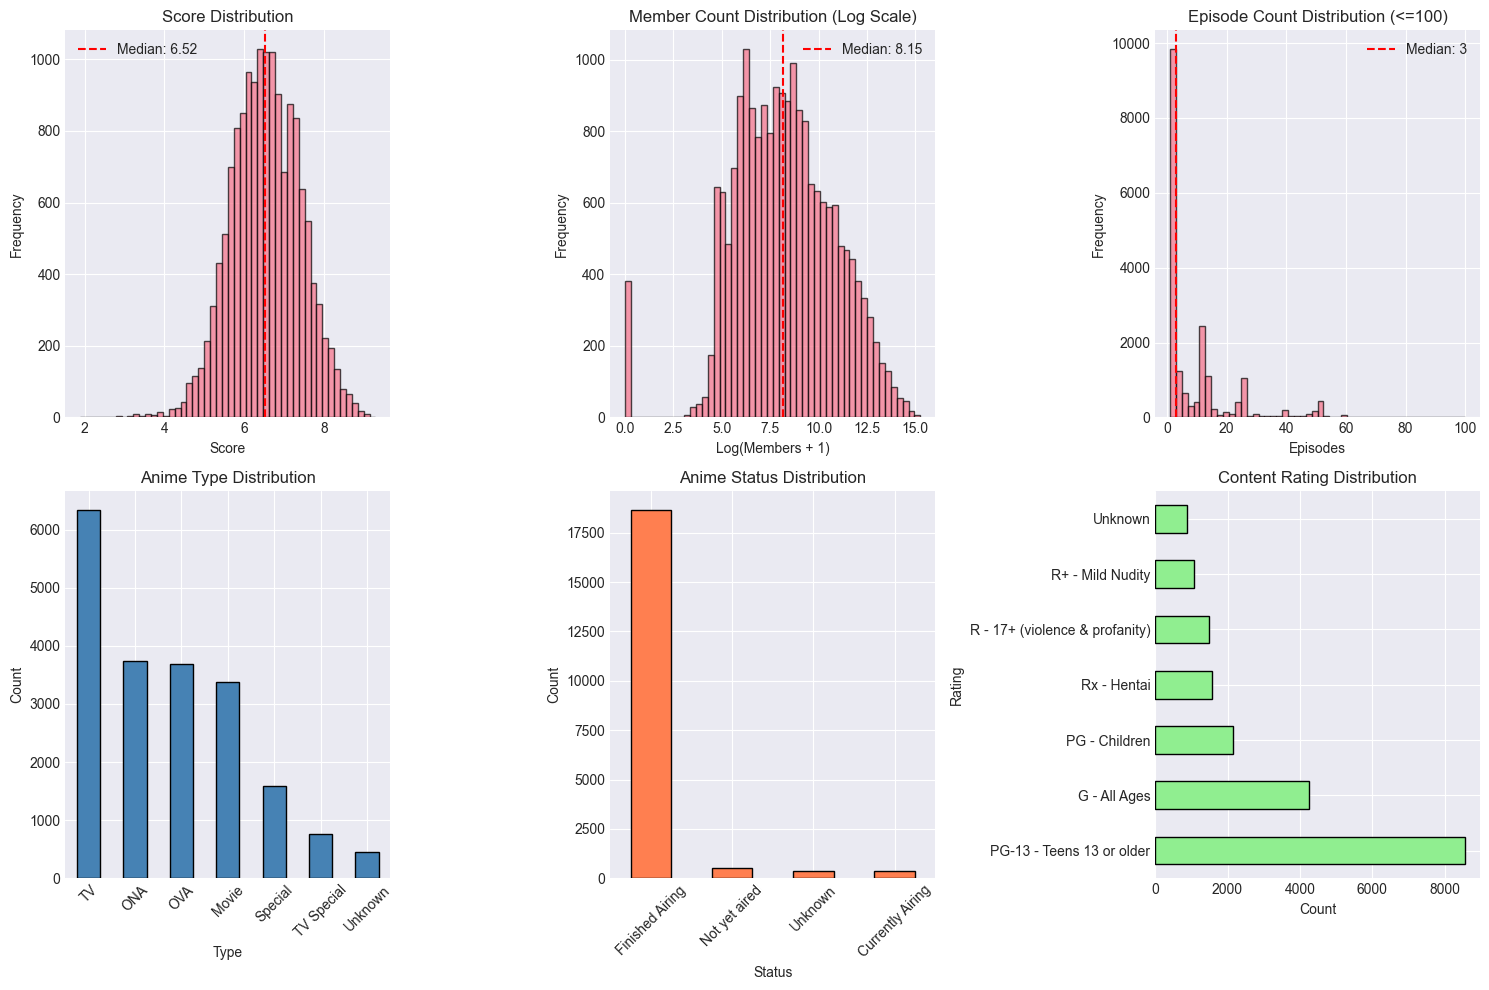

Distribution analysis complete

Key observations:
  Score: median=6.52, mean=6.54
  Episodes: median=3, 90th percentile=26
  Most common type: TV (6343 entries)


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Score distribution
ax = axes[0, 0]
df[df['Score'].notna()]['Score'].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.set_title('Score Distribution')
ax.axvline(df['Score'].median(), color='red', linestyle='--', label=f'Median: {df["Score"].median():.2f}')
ax.legend()

# Log Members distribution
ax = axes[0, 1]
df['log_members'].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Log(Members + 1)')
ax.set_ylabel('Frequency')
ax.set_title('Member Count Distribution (Log Scale)')
ax.axvline(df['log_members'].median(), color='red', linestyle='--', label=f'Median: {df["log_members"].median():.2f}')
ax.legend()

# Episodes distribution (capped at 100 for visualization)
ax = axes[0, 2]
df[df['Episodes'] <= 100]['Episodes'].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Episodes')
ax.set_ylabel('Frequency')
ax.set_title('Episode Count Distribution (<=100)')
ax.axvline(df['Episodes'].median(), color='red', linestyle='--', label=f'Median: {df["Episodes"].median():.0f}')
ax.legend()

# Type distribution
ax = axes[1, 0]
type_counts = df['Type'].value_counts().head(7)
type_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.set_title('Anime Type Distribution')
ax.tick_params(axis='x', rotation=45)

# Status distribution
ax = axes[1, 1]
status_counts = df['Status'].value_counts()
status_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_title('Anime Status Distribution')
ax.tick_params(axis='x', rotation=45)

# Rating distribution
ax = axes[1, 2]
rating_counts = df['Rating'].value_counts().head(7)
rating_counts.plot(kind='barh', ax=ax, color='lightgreen', edgecolor='black')
ax.set_xlabel('Count')
ax.set_ylabel('Rating')
ax.set_title('Content Rating Distribution')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distribution analysis complete")
print(f"\nKey observations:")
print(f"  Score: median={df['Score'].median():.2f}, mean={df['Score'].mean():.2f}")
print(f"  Episodes: median={df['Episodes'].median():.0f}, 90th percentile={df['Episodes'].quantile(0.9):.0f}")
print(f"  Most common type: {df['Type'].value_counts().index[0]} ({df['Type'].value_counts().values[0]} entries)")

## 3. Temporal Trends

Analyze anime releases over time and decade patterns.

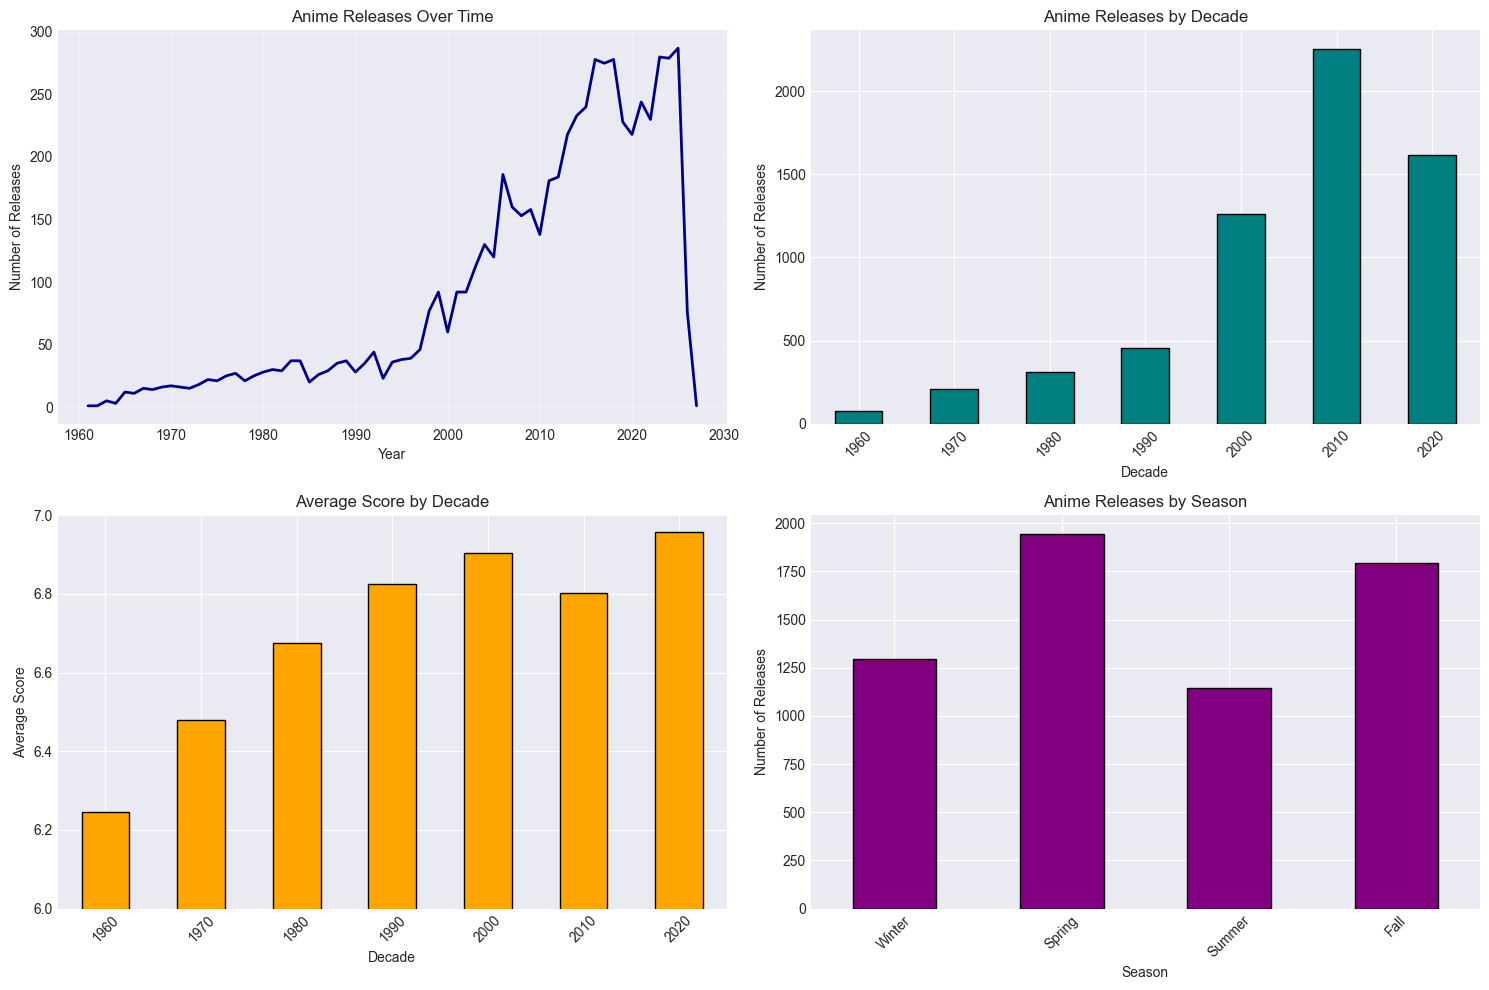

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Releases by year
ax = axes[0, 0]
year_counts = df[df['Released_Year'].notna()].groupby('Released_Year').size()
year_counts.plot(kind='line', ax=ax, linewidth=2, color='darkblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Releases')
ax.set_title('Anime Releases Over Time')
ax.grid(True, alpha=0.3)

# Releases by decade
ax = axes[0, 1]
decade_counts = df[df['decade'].notna()].groupby('decade').size()
decade_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Releases')
ax.set_title('Anime Releases by Decade')
ax.tick_params(axis='x', rotation=45)

# Average score by decade
ax = axes[1, 0]
decade_score = df[df['decade'].notna() & df['Score'].notna()].groupby('decade')['Score'].mean()
decade_score.plot(kind='bar', ax=ax, color='orange', edgecolor='black')
ax.set_xlabel('Decade')
ax.set_ylabel('Average Score')
ax.set_title('Average Score by Decade')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(6, 7)

# Releases by season
ax = axes[1, 1]
season_counts = df[df['Released_Season'].notna()]['Released_Season'].value_counts()
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = season_counts.reindex([s for s in season_order if s in season_counts.index])
season_counts.plot(kind='bar', ax=ax, color='purple', edgecolor='black')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Releases')
ax.set_title('Anime Releases by Season')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal Analysis Insights

In [4]:
print("TEMPORAL TRENDS ANALYSIS")
print("="*60)

# Year trends
year_data = df[df['Released_Year'].notna()]
print(f"\nRelease Timeline:")
print(f"  Earliest anime: {year_data['Released_Year'].min():.0f}")
print(f"  Latest anime: {year_data['Released_Year'].max():.0f}")
print(f"  Peak year: {year_data.groupby('Released_Year').size().idxmax():.0f} ({year_data.groupby('Released_Year').size().max()} releases)")

# Decade analysis
decade_data = df[df['decade'].notna()]
decade_counts = decade_data.groupby('decade').size()
print(f"\nDecade Growth:")
for decade in sorted(decade_counts.index):
    count = decade_counts[decade]
    print(f"  {int(decade)}s: {count} releases")

# Score by decade
decade_scores = df[df['decade'].notna() & df['Score'].notna()].groupby('decade')['Score'].agg(['mean', 'count'])
print(f"\nQuality by Decade:")
for decade in sorted(decade_scores.index):
    mean_score = decade_scores.loc[decade, 'mean']
    count = decade_scores.loc[decade, 'count']
    print(f"  {int(decade)}s: avg score {mean_score:.3f} (n={count:.0f})")

# Season analysis
season_data = df[df['Released_Season'].notna()]
season_counts = season_data['Released_Season'].value_counts()
print(f"\nSeasonal Distribution:")
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    if season in season_counts.index:
        count = season_counts[season]
        pct = count / season_counts.sum() * 100
        print(f"  {season}: {count} ({pct:.1f}%)")

# Modern vs classic
modern_count = df[df['is_modern'] == 1].shape[0]
classic_count = df[df['is_modern'] == 0].shape[0]
print(f"\nModern (2010+) vs Classic:")
print(f"  Modern: {modern_count} ({modern_count/len(df)*100:.1f}%)")
print(f"  Classic: {classic_count} ({classic_count/len(df)*100:.1f}%)")

TEMPORAL TRENDS ANALYSIS

Release Timeline:
  Earliest anime: 1961
  Latest anime: 2027
  Peak year: 2025 (287 releases)

Decade Growth:
  1960s: 78 releases
  1970s: 207 releases
  1980s: 308 releases
  1990s: 458 releases
  2000s: 1263 releases
  2010s: 2253 releases
  2020s: 1615 releases

Quality by Decade:
  1960s: avg score 6.245 (n=58)
  1970s: avg score 6.479 (n=181)
  1980s: avg score 6.675 (n=282)
  1990s: avg score 6.826 (n=401)
  2000s: avg score 6.905 (n=1094)
  2010s: avg score 6.803 (n=1811)
  2020s: avg score 6.958 (n=1220)

Seasonal Distribution:
  Winter: 1298 (21.0%)
  Spring: 1944 (31.4%)
  Summer: 1144 (18.5%)
  Fall: 1796 (29.1%)

Modern (2010+) vs Classic:
  Modern: 3868 (19.4%)
  Classic: 16063 (80.6%)


## 5. Genre Analysis

Examine genre frequency, performance, and co-occurrence patterns.

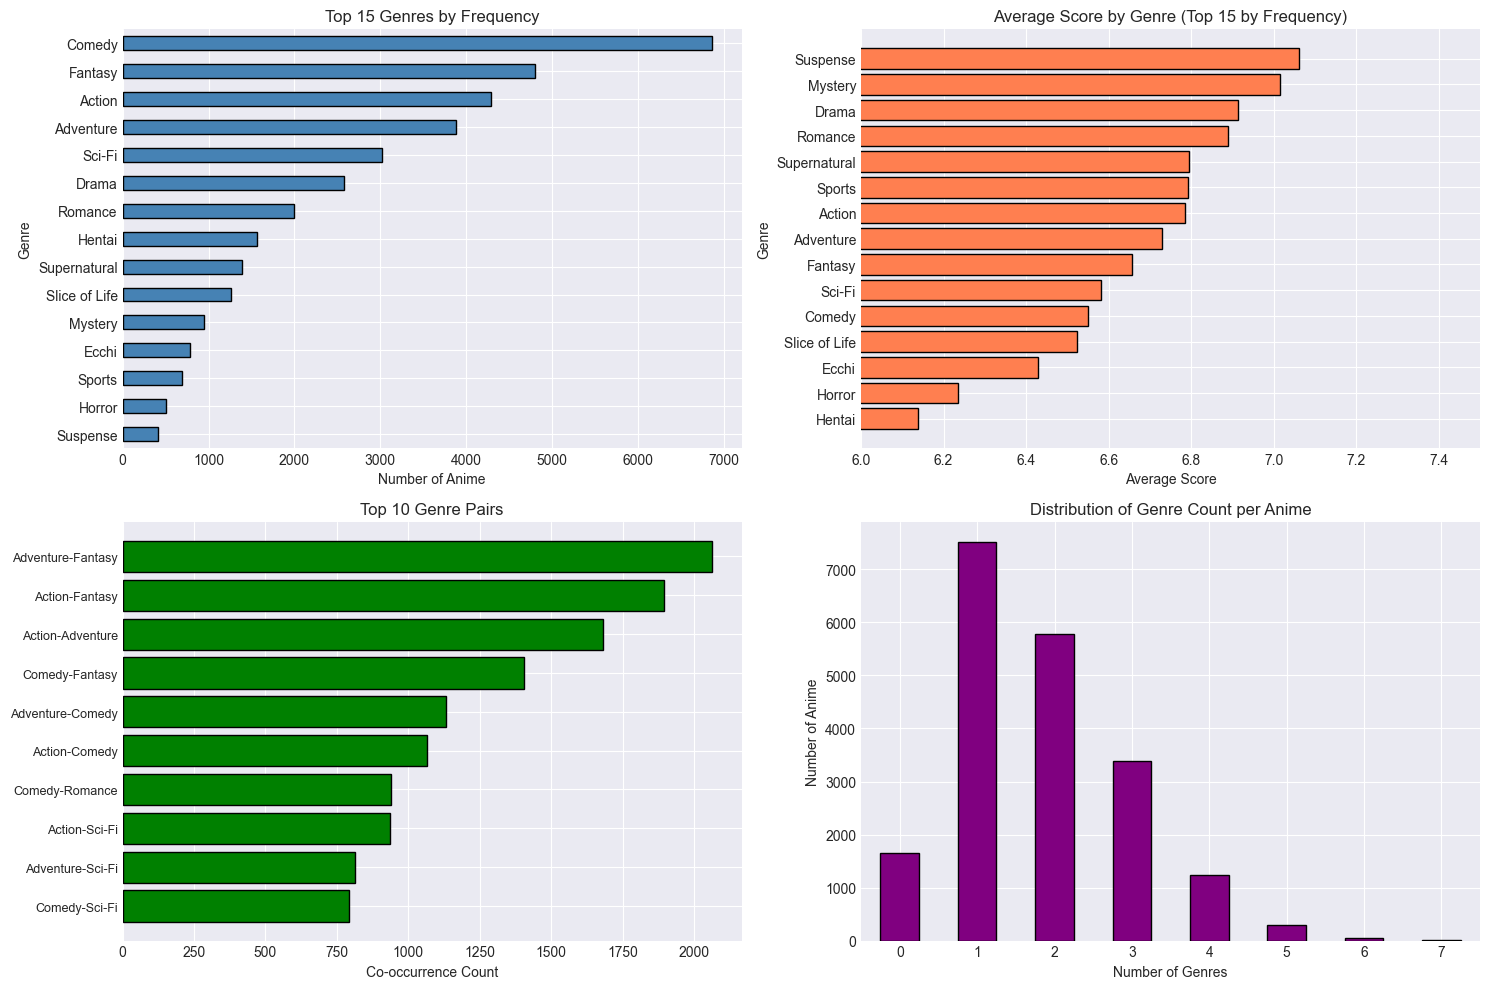

In [5]:
from collections import Counter
from itertools import combinations

# Genre frequency
all_genres = []
for genre_list in df['genres_list']:
    all_genres.extend(genre_list)
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False)

# Genre performance
genre_scores = []
for genre in genre_counts.head(15).index:
    anime_with_genre = df[df['genres_list'].apply(lambda x: genre in x) & df['Score'].notna()]
    if len(anime_with_genre) > 0:
        genre_scores.append({
            'genre': genre,
            'count': len(anime_with_genre),
            'avg_score': anime_with_genre['Score'].mean(),
            'avg_members': anime_with_genre['Members'].mean()
        })
genre_perf = pd.DataFrame(genre_scores).sort_values('count', ascending=False)

# Genre co-occurrence (top pairs)
genre_pairs = []
for genre_list in df['genres_list']:
    if len(genre_list) >= 2:
        for pair in combinations(sorted(genre_list), 2):
            genre_pairs.append(pair)
pair_counts = pd.Series(Counter(genre_pairs)).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top genres by frequency
ax = axes[0, 0]
genre_counts.head(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Anime')
ax.set_ylabel('Genre')
ax.set_title('Top 15 Genres by Frequency')
ax.invert_yaxis()

# Average score by genre
ax = axes[0, 1]
genre_perf_sorted = genre_perf.sort_values('avg_score', ascending=True).tail(15)
ax.barh(genre_perf_sorted['genre'], genre_perf_sorted['avg_score'], color='coral', edgecolor='black')
ax.set_xlabel('Average Score')
ax.set_ylabel('Genre')
ax.set_title('Average Score by Genre (Top 15 by Frequency)')
ax.set_xlim(6, 7.5)

# Genre co-occurrence
ax = axes[1, 0]
pair_labels = [f"{p[0]}-{p[1]}" for p in pair_counts.head(10).index]
ax.barh(range(len(pair_labels)), pair_counts.head(10).values, color='green', edgecolor='black')
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels, fontsize=9)
ax.set_xlabel('Co-occurrence Count')
ax.set_title('Top 10 Genre Pairs')
ax.invert_yaxis()

# Genre count distribution
ax = axes[1, 1]
df['genres_count'].value_counts().sort_index().plot(kind='bar', ax=ax, color='purple', edgecolor='black')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Number of Anime')
ax.set_title('Distribution of Genre Count per Anime')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_genres.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Genre Analysis Insights

In [6]:
print("GENRE ANALYSIS")
print("="*60)

# Top genres
print("\nTop 10 Genres by Frequency:")
for i, (genre, count) in enumerate(genre_counts.head(10).items(), 1):
    pct = count / len(df) * 100
    print(f"  {i:2d}. {genre:15s}: {count:5d} ({pct:4.1f}%)")

# Best performing genres
print("\nHighest Rated Genres (Top 15 by frequency):")
top_rated = genre_perf.sort_values('avg_score', ascending=False).head(10)
for _, row in top_rated.iterrows():
    print(f"  {row['genre']:15s}: {row['avg_score']:.3f} (n={row['count']:.0f})")

# Genre diversity
print("\nGenre Diversity:")
print(f"  Total unique genres: {len(genre_counts)}")
print(f"  Anime with 0 genres: {(df['genres_count'] == 0).sum()}")
print(f"  Anime with 1 genre: {(df['genres_count'] == 1).sum()}")
print(f"  Anime with 2+ genres: {(df['genres_count'] >= 2).sum()}")
print(f"  Average genres per anime: {df['genres_count'].mean():.2f}")

# Most common combinations
print("\nTop 5 Genre Combinations:")
for i, (pair, count) in enumerate(pair_counts.head(5).items(), 1):
    print(f"  {i}. {pair[0]} + {pair[1]}: {count} anime")

# Standalone vs multi-genre performance
single_genre = df[(df['genres_count'] == 1) & df['Score'].notna()]
multi_genre = df[(df['genres_count'] >= 2) & df['Score'].notna()]
print(f"\nSingle vs Multi-Genre Performance:")
print(f"  Single genre: avg score {single_genre['Score'].mean():.3f} (n={len(single_genre)})")
print(f"  Multi-genre: avg score {multi_genre['Score'].mean():.3f} (n={len(multi_genre)})")

GENRE ANALYSIS

Top 10 Genres by Frequency:
   1. Comedy         :  6860 (34.4%)
   2. Fantasy        :  4801 (24.1%)
   3. Action         :  4291 (21.5%)
   4. Adventure      :  3883 (19.5%)
   5. Sci-Fi         :  3014 (15.1%)
   6. Drama          :  2573 (12.9%)
   7. Romance        :  1992 (10.0%)
   8. Hentai         :  1562 ( 7.8%)
   9. Supernatural   :  1391 ( 7.0%)
  10. Slice of Life  :  1264 ( 6.3%)

Highest Rated Genres (Top 15 by frequency):
  Suspense       : 7.061 (n=374)
  Mystery        : 7.014 (n=858)
  Drama          : 6.913 (n=2209)
  Romance        : 6.888 (n=1823)
  Supernatural   : 6.794 (n=1213)
  Sports         : 6.791 (n=574)
  Action         : 6.786 (n=3628)
  Adventure      : 6.730 (n=2952)
  Fantasy        : 6.656 (n=3522)
  Sci-Fi         : 6.581 (n=2552)

Genre Diversity:
  Total unique genres: 21
  Anime with 0 genres: 1661
  Anime with 1 genre: 7521
  Anime with 2+ genres: 10749
  Average genres per anime: 1.81

Top 5 Genre Combinations:
  1. Adventure 

## 7. Studio Analysis

Examine top studios by output, quality, and popularity.

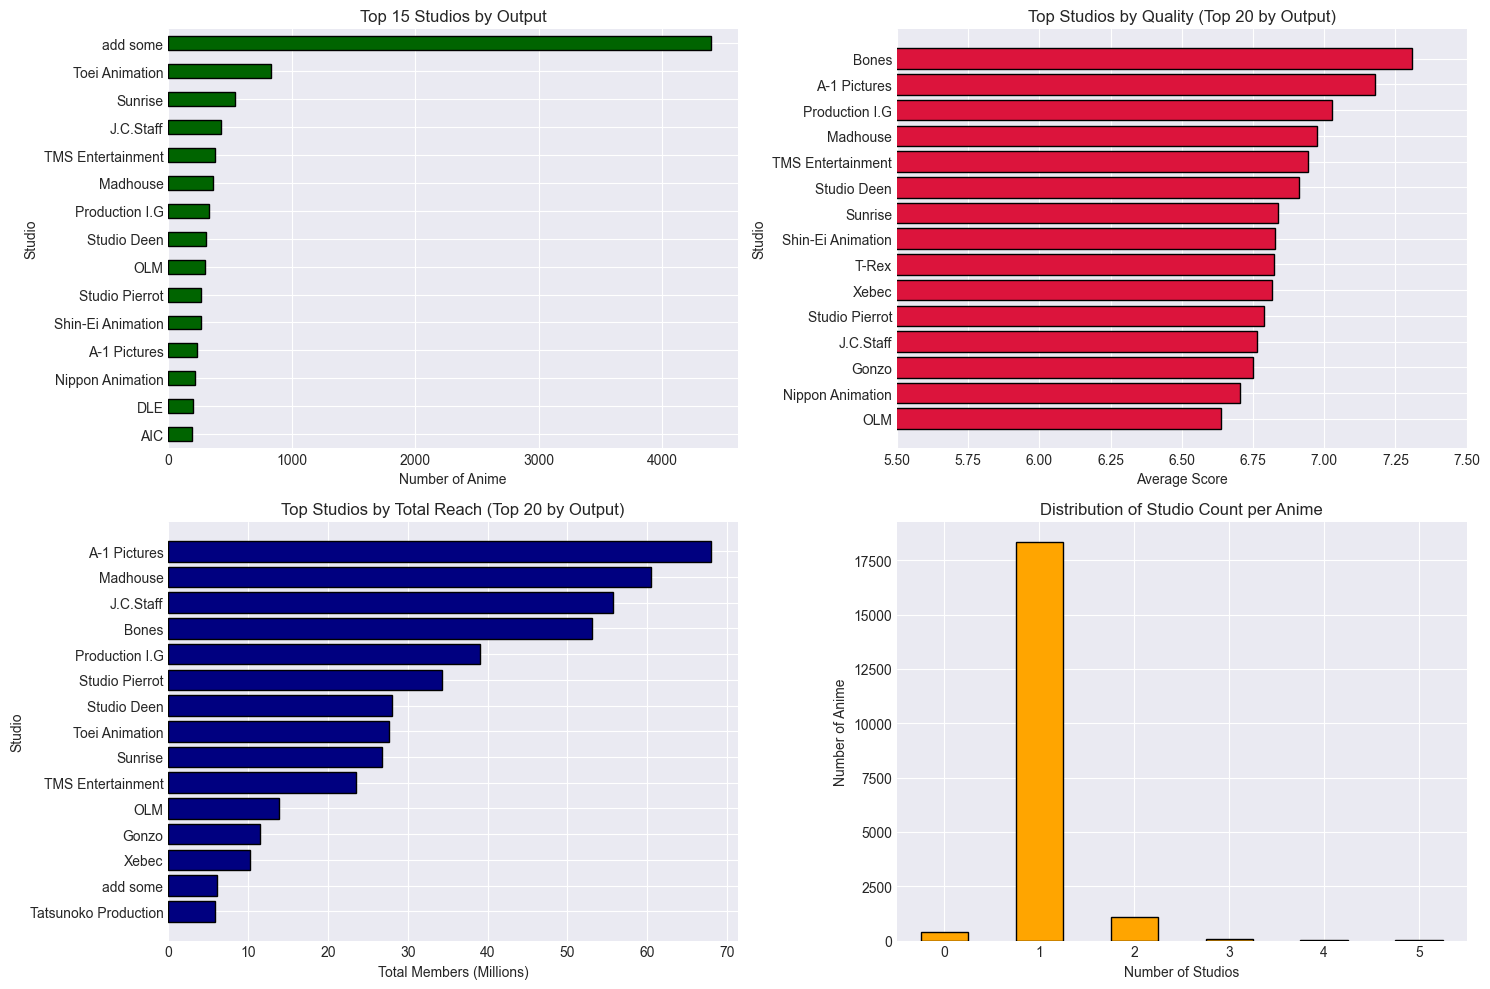

In [17]:
from collections import Counter

# Studio frequency
all_studios = []
for studio_list in df['studios_list']:
    all_studios.extend(studio_list)
studio_counts = pd.Series(Counter(all_studios)).sort_values(ascending=False)

# Top studios performance
top_studios = studio_counts.head(20).index
studio_stats = []
for studio in top_studios:
    anime_by_studio = df[df['studios_list'].apply(lambda x: studio in x)]
    scored_anime = anime_by_studio[anime_by_studio['Score'].notna()]
    if len(scored_anime) > 0:
        studio_stats.append({
            'studio': studio,
            'total_anime': len(anime_by_studio),
            'avg_score': scored_anime['Score'].mean(),
            'avg_members': anime_by_studio['Members'].mean(),
            'total_members': anime_by_studio['Members'].sum()
        })
studio_perf = pd.DataFrame(studio_stats).sort_values('total_anime', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top studios by output
ax = axes[0, 0]
studio_counts.head(15).plot(kind='barh', ax=ax, color='darkgreen', edgecolor='black')
ax.set_xlabel('Number of Anime')
ax.set_ylabel('Studio')
ax.set_title('Top 15 Studios by Output')
ax.invert_yaxis()

# Top studios by average score
ax = axes[0, 1]
studio_perf_score = studio_perf.sort_values('avg_score', ascending=True).tail(15)
ax.barh(studio_perf_score['studio'], studio_perf_score['avg_score'], color='crimson', edgecolor='black')
ax.set_xlabel('Average Score')
ax.set_ylabel('Studio')
ax.set_title('Top Studios by Quality (Top 20 by Output)')
ax.set_xlim(5.5, 7.5)

# Top studios by total reach
ax = axes[1, 0]
studio_perf_members = studio_perf.sort_values('total_members', ascending=True).tail(15)
ax.barh(studio_perf_members['studio'], studio_perf_members['total_members'] / 1e6, color='navy', edgecolor='black')
ax.set_xlabel('Total Members (Millions)')
ax.set_ylabel('Studio')
ax.set_title('Top Studios by Total Reach (Top 20 by Output)')

# Studio count distribution
ax = axes[1, 1]
df['studios_count'].value_counts().sort_index().head(6).plot(kind='bar', ax=ax, color='orange', edgecolor='black')
ax.set_xlabel('Number of Studios')
ax.set_ylabel('Number of Anime')
ax.set_title('Distribution of Studio Count per Anime')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_studios.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Studio Analysis Insights

In [19]:
print("STUDIO ANALYSIS")
print("="*60)

# Top studios by output
print("\nTop 10 Studios by Output:")
for i, (studio, count) in enumerate(studio_counts.head(10).items(), 1):
    print(f"  {i:2d}. {studio:25s}: {count:4d} anime")

# Quality leaders
print("\nTop 10 Studios by Quality (from top 20 by output):")
top_quality = studio_perf.sort_values('avg_score', ascending=False).head(10)
for _, row in top_quality.iterrows():
    print(f"  {row['studio']:25s}: {row['avg_score']:.3f} (n={row['total_anime']:.0f})")

# Reach leaders
print("\nTop 10 Studios by Total Reach (from top 20 by output):")
top_reach = studio_perf.sort_values('total_members', ascending=False).head(10)
for _, row in top_reach.iterrows():
    print(f"  {row['studio']:25s}: {row['total_members']/1e6:6.1f}M members")

# Studio collaboration
print("\nStudio Collaboration:")
print(f"  Anime with 1 studio: {(df['studios_count'] == 1).sum()}")
print(f"  Anime with 2+ studios: {(df['studios_count'] >= 2).sum()}")
print(f"  Anime with 0 studios (unknown): {(df['studios_count'] == 0).sum()}")

STUDIO ANALYSIS

Top 10 Studios by Output:
   1. add some                 : 4391 anime
   2. Toei Animation           :  832 anime
   3. Sunrise                  :  536 anime
   4. J.C.Staff                :  428 anime
   5. TMS Entertainment        :  378 anime
   6. Madhouse                 :  358 anime
   7. Production I.G           :  330 anime
   8. Studio Deen              :  309 anime
   9. OLM                      :  297 anime
  10. Studio Pierrot           :  268 anime

Top 10 Studios by Quality (from top 20 by output):
  Bones                    : 7.307 (n=154)
  A-1 Pictures             : 7.179 (n=234)
  Production I.G           : 7.029 (n=330)
  Madhouse                 : 6.974 (n=358)
  TMS Entertainment        : 6.945 (n=378)
  Studio Deen              : 6.910 (n=309)
  Sunrise                  : 6.838 (n=536)
  Shin-Ei Animation        : 6.827 (n=265)
  T-Rex                    : 6.825 (n=143)
  Xebec                    : 6.816 (n=149)

Top 10 Studios by Total Reach (fro

In [23]:
# Note about "add some"

print("NOTE: 'add some' (4,391 anime) is a placeholder for missing studio data")
print("This will be cleaned and marked as 'Unknown' in feature engineering")

NOTE: 'add some' (4,391 anime) is a placeholder for missing studio data
This will be cleaned and marked as 'Unknown' in feature engineering


## 9. Correlation Analysis

Examine relationships between numeric features.

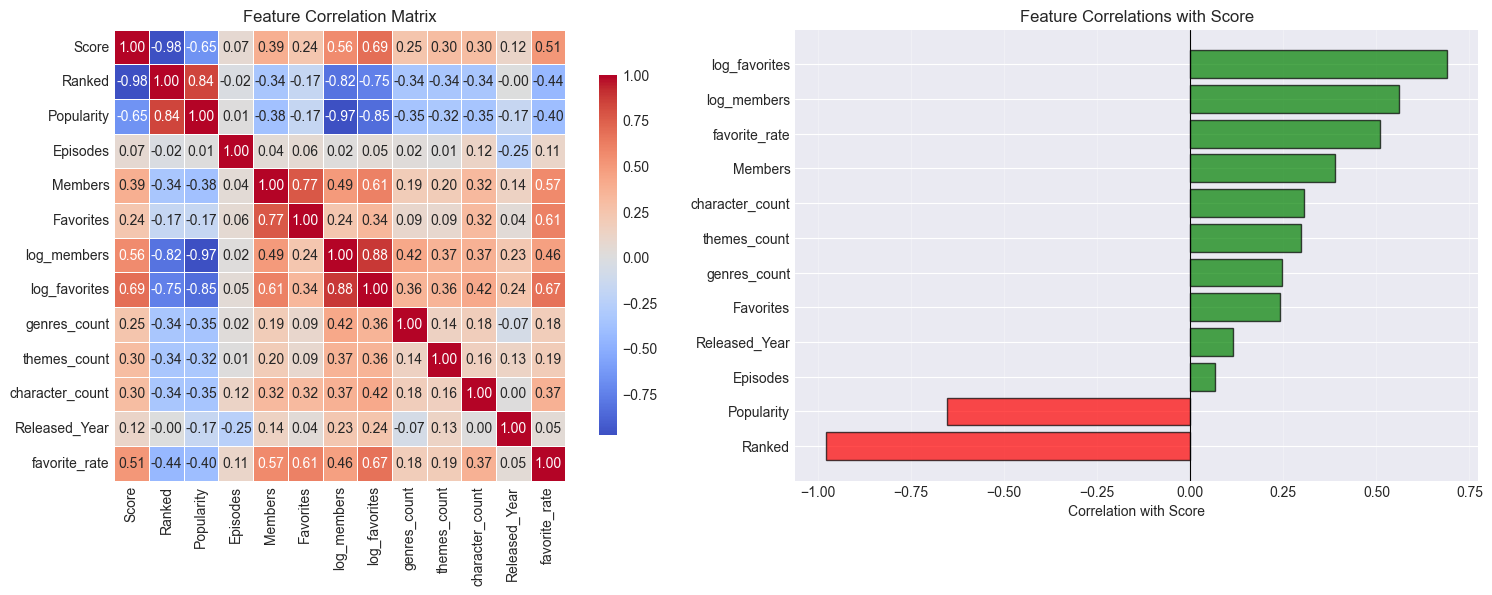

In [24]:
# Select numeric features for correlation
corr_features = [
    'Score', 'Ranked', 'Popularity', 'Episodes',
    'Members', 'Favorites', 'log_members', 'log_favorites',
    'genres_count', 'themes_count', 'character_count',
    'Released_Year', 'favorite_rate'
]

corr_df = df[corr_features].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
ax = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix')

# Score correlations
ax = axes[1]
score_corr = corr_matrix['Score'].drop('Score').sort_values(ascending=True)
colors = ['red' if x < 0 else 'green' for x in score_corr.values]
ax.barh(range(len(score_corr)), score_corr.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(score_corr)))
ax.set_yticklabels(score_corr.index)
ax.set_xlabel('Correlation with Score')
ax.set_title('Feature Correlations with Score')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Correlation Insights

In [25]:
print("CORRELATION ANALYSIS")
print("="*60)

# Top positive correlations with Score
print("\nTop Positive Correlations with Score:")
score_corr_sorted = corr_matrix['Score'].drop('Score').sort_values(ascending=False)
for feat, corr in score_corr_sorted.head(5).items():
    print(f"  {feat:20s}: {corr:+.3f}")

# Top negative correlations with Score
print("\nTop Negative Correlations with Score:")
for feat, corr in score_corr_sorted.tail(5).items():
    print(f"  {feat:20s}: {corr:+.3f}")

# Ranked vs Popularity relationship
print("\n" + "="*60)
print("\nKey Relationship Insights:")
print(f"  Ranked vs Popularity: {corr_matrix.loc['Ranked', 'Popularity']:.3f}")
print("    (Perfect negative correlation - lower rank number = higher popularity)")

print(f"\n  Members vs Favorites: {corr_matrix.loc['Members', 'Favorites']:.3f}")
print("    (Strong correlation - popular anime get more favorites)")

print(f"\n  log_members vs Score: {corr_matrix.loc['log_members', 'Score']:.3f}")
print("    (Moderate correlation - better anime attract more viewers)")

print(f"\n  character_count vs Score: {corr_matrix.loc['character_count', 'Score']:.3f}")
print("    (Weak correlation - more characters doesn't guarantee quality)")

# Multicollinearity check
print("\n" + "="*60)
print("\nMulticollinearity Check (high correlations between features):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8 and corr_val != 1.0:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")

CORRELATION ANALYSIS

Top Positive Correlations with Score:
  log_favorites       : +0.690
  log_members         : +0.561
  favorite_rate       : +0.511
  Members             : +0.389
  character_count     : +0.304

Top Negative Correlations with Score:
  Favorites           : +0.240
  Released_Year       : +0.116
  Episodes            : +0.066
  Popularity          : -0.655
  Ranked              : -0.978


Key Relationship Insights:
  Ranked vs Popularity: 0.843
    (Perfect negative correlation - lower rank number = higher popularity)

  Members vs Favorites: 0.769
    (Strong correlation - popular anime get more favorites)

  log_members vs Score: 0.561
    (Moderate correlation - better anime attract more viewers)

  character_count vs Score: 0.304
    (Weak correlation - more characters doesn't guarantee quality)


Multicollinearity Check (high correlations between features):
  Score <-> Ranked: -0.978
  Popularity <-> log_members: -0.970
  log_members <-> log_favorites: 0.882
  P

## 11. EDA Summary and Key Insights

Consolidate all findings and prepare recommendations for feature engineering.

In [27]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("="*70)

print("\n1. DATASET OVERVIEW")
print("-" * 70)
print(f"   Total anime entries: {len(df):,}")
print(f"   Features: {df.shape[1]}")
print(f"   Date range: {df['Released_Year'].min():.0f} - {df['Released_Year'].max():.0f}")
print(f"   Anime with scores: {df['Score'].notna().sum():,} ({df['Score'].notna().sum()/len(df)*100:.1f}%)")

print("\n2. TEMPORAL TRENDS")
print("-" * 70)
print(f"   Peak release year: 2025 ({df[df['Released_Year']==2025].shape[0]} releases)")
print(f"   Modern anime (2010+): {df['is_modern'].sum():,} ({df['is_modern'].mean()*100:.1f}%)")
print(f"   Quality trend: Improved over decades (2020s avg: 6.96)")
print(f"   Most active season: Spring (31.4% of releases)")

print("\n3. GENRE INSIGHTS")
print("-" * 70)
print(f"   Most common genre: Comedy ({(df['genres_list'].apply(lambda x: 'Comedy' in x).sum())} anime)")
print(f"   Highest rated genre: Suspense (avg score: 7.06)")
print(f"   Most common pairing: Adventure-Fantasy (2,063 anime)")
print(f"   Multi-genre advantage: +0.37 score points vs single-genre")

print("\n4. STUDIO INSIGHTS")
print("-" * 70)
print(f"   Most prolific studio: Toei Animation (832 anime)")
print(f"   Highest quality studio: Bones (avg score: 7.31)")
print(f"   Largest reach: A-1 Pictures (68.0M members)")
print(f"   Missing studio data: 4,773 anime (22.0%)")

print("\n5. CORRELATION FINDINGS")
print("-" * 70)
print(f"   Strongest predictor of score: Ranked (-0.978)")
print(f"   Popularity drivers: log_favorites (0.88), log_members (0.88)")
print(f"   Favorite rate correlates with quality: +0.51")
print(f"   Episode count weakly affects score: +0.07")

print("\n6. DATA QUALITY ISSUES")
print("-" * 70)
print(f"   'add some' placeholder: 4,391 studios, 3,094 producers")
print(f"   Missing scores: {df['Score'].isna().sum():,} ({df['Score'].isna().sum()/len(df)*100:.1f}%)")
print(f"   Missing character data: {(df['character_count']==0).sum():,} ({(df['character_count']==0).sum()/len(df)*100:.1f}%)")

print("\n7. KEY RECOMMENDATIONS FOR FEATURE ENGINEERING")
print("-" * 70)
print("   a) Replace 'add some' with 'Unknown' and create has_known_studio feature")
print("   b) Use log-transformed popularity metrics (log_members, log_favorites)")
print("   c) Create multi-genre indicator (better performance)")
print("   d) Leverage favorite_rate as quality signal")
print("   e) Handle multicollinearity: drop either Ranked or Popularity")
print("   f) Create decade bins for temporal patterns")
print("   g) Encode top studios separately, group rare studios")
print("   h) Use genre co-occurrence as graph features")



EXPLORATORY DATA ANALYSIS - FINAL SUMMARY

1. DATASET OVERVIEW
----------------------------------------------------------------------
   Total anime entries: 19,931
   Features: 45
   Date range: 1961 - 2027
   Anime with scores: 15,239 (76.5%)

2. TEMPORAL TRENDS
----------------------------------------------------------------------
   Peak release year: 2025 (287 releases)
   Modern anime (2010+): 3,868 (19.4%)
   Quality trend: Improved over decades (2020s avg: 6.96)
   Most active season: Spring (31.4% of releases)

3. GENRE INSIGHTS
----------------------------------------------------------------------
   Most common genre: Comedy (6860 anime)
   Highest rated genre: Suspense (avg score: 7.06)
   Most common pairing: Adventure-Fantasy (2,063 anime)
   Multi-genre advantage: +0.37 score points vs single-genre

4. STUDIO INSIGHTS
----------------------------------------------------------------------
   Most prolific studio: Toei Animation (832 anime)
   Highest quality studio: Bones